# 🗑️ Klasifikasi Sampah B3 vs Non-B3
**Transfer Learning dengan MobileNetV2 — Google Colab Edition**

Dataset: Classification Sampah B3 (Roboflow)
- Train : ~14.771 gambar (B3: 3.960 | non-B3: 10.811)
- Valid : ~1.413 gambar (B3: 376 | non-B3: 1.037)
- Test  : ~707 gambar (B3: 195 | non-B3: 512)

> ⚠️ **Pastikan Runtime → Change runtime type → T4 GPU sudah aktif sebelum menjalankan notebook ini!**

## 0. ✅ Cek GPU & Mount Google Drive

In [6]:
# Cek GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {gpus}")
if not gpus:
    print("⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU")
else:
    print("✅ GPU siap digunakan!")

TensorFlow : 2.21.0
GPU        : []
⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU


In [7]:
# Local environment setup - tidak perlu mount Google Drive
# Dataset dimulai dari folder lokal
print("✅ Environment setup selesai")

✅ Environment setup selesai


## 1. 📦 Ekstrak Dataset dari ZIP

In [12]:
import zipfile
import os
from pathlib import Path

# ── Path lokal ─────────────────────────────────────────────────────────────
ZIP_PATH    = Path("./dataset/dataset.zip")  # ← ubah ke Path
EXTRACT_DIR = Path("./dataset")              # ← ubah ke Path

# Cek apakah file dataset.zip sudah ada
if not ZIP_PATH.exists():
    print(f"❌ {ZIP_PATH} tidak ditemukan!")
    print("   Download dataset dari Roboflow dan letakkan di folder project/dataset/")
    print("   atau ubah ZIP_PATH di atas sesuai lokasi file Anda")
else:
    # Cek apakah sudah pernah diekstrak
    if not (EXTRACT_DIR / "train").exists():  # ← sekarang berfungsi
        print(f"Mengekstrak {ZIP_PATH} ...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        print(f"✅ Ekstraksi selesai → {EXTRACT_DIR}")
    else:
        print(f"✅ Dataset sudah ada di {EXTRACT_DIR}, skip ekstraksi.")

    # Tampilkan struktur folder hasil ekstraksi
    print("\nStruktur dataset:")
    for split in ["train", "valid", "test"]:
        for cls in ["B3", "non-B3"]:
            folder = EXTRACT_DIR / split / cls
            if folder.exists():
                n = len(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))
                print(f"   {split:5s}/{cls:6s} → {n:5d} gambar")
            else:
                print(f"   ⚠️  {split}/{cls} tidak ditemukan!")

Mengekstrak dataset\dataset.zip ...
✅ Ekstraksi selesai → dataset

Struktur dataset:
   train/B3     →  3960 gambar
   train/non-B3 → 10811 gambar
   valid/B3     →   376 gambar
   valid/non-B3 →  1037 gambar
   test /B3     →   195 gambar
   test /non-B3 →   512 gambar


## 2. 📚 Import Library

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print("✅ Semua library berhasil di-import")

✅ Semua library berhasil di-import


## 3. ⚙️ Konfigurasi Path & Hyperparameter

In [14]:
# ── Path dataset (lokal) ──────────────────────────────────────────────────
DATASET_DIR = Path(EXTRACT_DIR)
TRAIN_DIR   = DATASET_DIR / "train"
VALID_DIR   = DATASET_DIR / "valid"
TEST_DIR    = DATASET_DIR / "test"

# ── Path simpan model (lokal, di folder project) ──────────────────────────
PROJECT_DIR    = Path("./")  # folder project ini
MODEL_PATH     = PROJECT_DIR / "model_b3.h5"
CKPT_PATH      = PROJECT_DIR / "checkpoint_best.h5"

# ── Hyperparameter ────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FT  = 10    # Fase 1: head training (base frozen)
EPOCHS_UN  = 20    # Fase 2: fine-tuning (partial unfreeze)
SEED       = 42

print(f"Train : {TRAIN_DIR}  | exists: {TRAIN_DIR.exists()}")
print(f"Valid : {VALID_DIR}  | exists: {VALID_DIR.exists()}")
print(f"Test  : {TEST_DIR}   | exists: {TEST_DIR.exists()}")
print(f"Model akan disimpan ke: {MODEL_PATH}")

Train : dataset\train  | exists: True
Valid : dataset\valid  | exists: True
Test  : dataset\test   | exists: True
Model akan disimpan ke: model_b3.h5


## 4. 📂 Load Dataset

In [15]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="binary",
    interpolation="bilinear",
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print(f"Kelas terdeteksi : {CLASS_NAMES}")
print(f"Batch train      : {len(train_ds)}")
print(f"Batch valid      : {len(valid_ds)}")
print(f"Batch test       : {len(test_ds)}")

Found 14771 files belonging to 2 classes.
Found 1413 files belonging to 2 classes.
Found 707 files belonging to 2 classes.
Kelas terdeteksi : ['B3', 'non-B3']
Batch train      : 462
Batch valid      : 45
Batch test       : 23


## 5. ⚖️ Hitung Class Weight (Penanganan Imbalance)

In [16]:
all_labels = np.concatenate([y.numpy() for _, y in train_ds]).flatten().astype(int)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weight:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:8s} → weight = {class_weight_dict[idx]:.4f}")

Class weight:
  [0] B3       → weight = 1.8650
  [1] non-B3   → weight = 0.6831


## 6. 🔄 Preprocessing & Augmentasi

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = preprocess_input(images)
    return images, labels

def preprocess_eval(images, labels):
    images = preprocess_input(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds_proc = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_ds_proc = valid_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_proc  = test_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("✅ Pipeline preprocessing & augmentasi siap")

✅ Pipeline preprocessing & augmentasi siap


## 7. 🖼️ Visualisasi Sampel Dataset

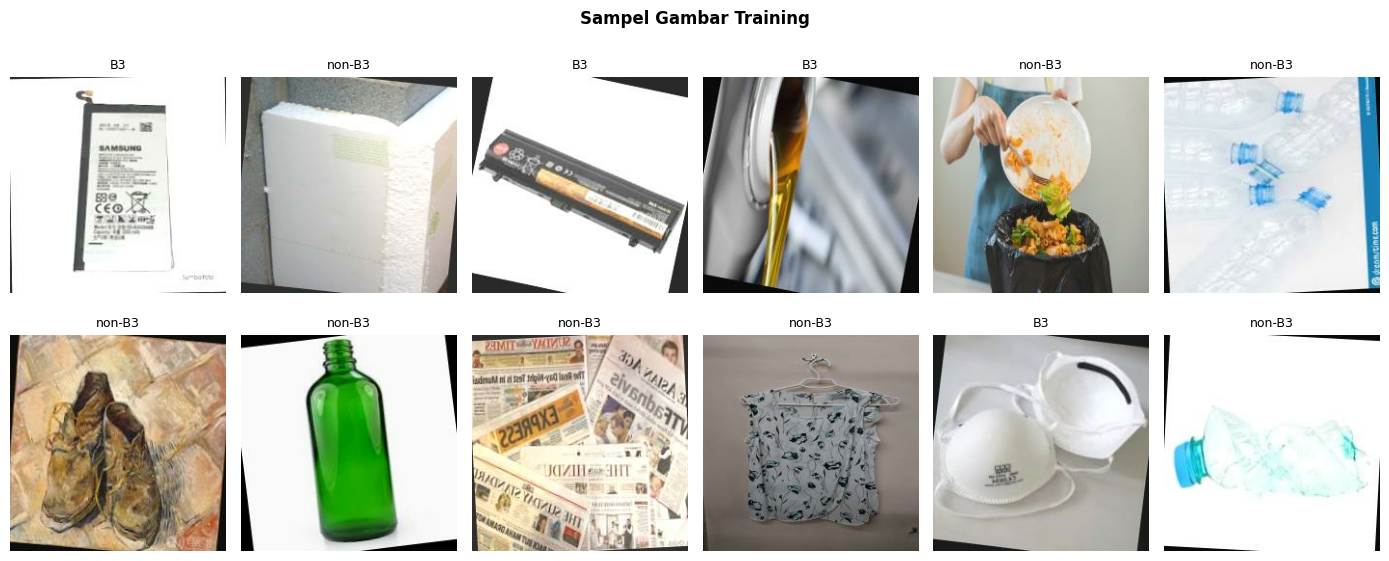

In [21]:
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy().item())], fontsize=9)
        plt.axis("off")
plt.suptitle("Sampel Gambar Training", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. 🏗️ Bangun Model (MobileNetV2 Transfer Learning)

In [22]:
def build_model(trainable_base=False):
    base_model = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    x = base_model(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, outputs, name="b3_classifier")
    return model, base_model

model, base_model = build_model(trainable_base=False)
model.summary()

Model: "b3_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 9. 🔥 Fase 1 — Training Head (Base Frozen)

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_auc", patience=4, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                     min_lr=1e-6, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("=" * 60)
print("FASE 1: Training head — base MobileNetV2 di-freeze")
print("=" * 60)

history1 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_FT,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1,
)

FASE 1: Training head — base MobileNetV2 di-freeze
Epoch 1/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.7900 - auc: 0.8632 - loss: 0.4752 - precision: 0.9072 - recall: 0.7912
Epoch 1: val_auc improved from None to 0.97448, saving model to checkpoint_best.h5



Epoch 1: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 162s 341ms/step - accuracy: 0.8397 - auc: 0.9151 - loss: 0.3788 - precision: 0.9344 - recall: 0.8399 - val_accuracy: 0.9250 - val_auc: 0.9745 - val_loss: 0.1877 - val_precision: 0.9568 - val_recall: 0.9402 - learning_rate: 0.0010
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8889 - auc: 0.9570 - loss: 0.2679 - precision: 0.9551 - recall: 0.8891
Epoch 2: val_auc improved from 0.97448 to 0.98024, saving model to checkpoint_best.h5



Epoch 2: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 148s 318ms/step - accuracy: 0.8952 - auc: 0.9611 - loss: 0.2538 - precision: 0.9599 - recall: 0.8942 - val_accuracy: 0.9363 - val_auc: 0.9802 - val_loss: 0.1560 - val_precision: 0.9611 - val_recall: 0.9518 - learning_rate: 0.0010
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9061 - auc: 0.9691 - loss: 0.2265 - precision: 0.9667 - recall: 0.9021
Epoch 3: val_auc improved from 0.98024 to 0.98470, saving model to checkpoint_best.h5



Epoch 3: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 141s 304ms/step - accuracy: 0.9100 - auc: 0.9709 - loss: 0.2183 - precision: 0.9682 - recall: 0.9069 - val_accuracy: 0.9455 - val_auc: 0.9847 - val_loss: 0.1401 - val_precision: 0.9724 - val_recall: 0.9527 - learning_rate: 0.0010
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9204 - auc: 0.9787 - loss: 0.1862 - precision: 0.9734 - recall: 0.9159
Epoch 4: val_auc did not improve from 0.98470
462/462 ━━━━━━━━━━━━━━━━━━━━ 138s 297ms/step - accuracy: 0.9209 - auc: 0.9781 - loss: 0.1886 - precision: 0.9728 - recall: 0.9176 - val_accuracy: 0.9476 - val_auc: 0.9833 - val_loss: 0.1420 - val_precision: 0.9744 - val_recall: 0.9537 - learning_rate: 0.0010
Epoch 5/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9218 - auc: 0.9801 - loss: 0.1810 - precision: 0.9737 - recall: 0.9172
Epoch 5: val_auc did not improve from 0.98470
462/462 ━━━━━━━━━━━━━━━━━━━━ 136s 292ms/step - accuracy: 0


Epoch 6: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 138s 296ms/step - accuracy: 0.9340 - auc: 0.9840 - loss: 0.1595 - precision: 0.9766 - recall: 0.9321 - val_accuracy: 0.9512 - val_auc: 0.9849 - val_loss: 0.1288 - val_precision: 0.9699 - val_recall: 0.9634 - learning_rate: 0.0010
Epoch 7/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9358 - auc: 0.9839 - loss: 0.1636 - precision: 0.9784 - recall: 0.9323
Epoch 7: val_auc improved from 0.98494 to 0.98663, saving model to checkpoint_best.h5



Epoch 7: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 136s 292ms/step - accuracy: 0.9391 - auc: 0.9853 - loss: 0.1530 - precision: 0.9795 - recall: 0.9365 - val_accuracy: 0.9519 - val_auc: 0.9866 - val_loss: 0.1263 - val_precision: 0.9699 - val_recall: 0.9643 - learning_rate: 0.0010
Epoch 8/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9449 - auc: 0.9874 - loss: 0.1411 - precision: 0.9828 - recall: 0.9406
Epoch 8: val_auc did not improve from 0.98663
462/462 ━━━━━━━━━━━━━━━━━━━━ 140s 301ms/step - accuracy: 0.9435 - auc: 0.9875 - loss: 0.1401 - precision: 0.9824 - recall: 0.9397 - val_accuracy: 0.9554 - val_auc: 0.9850 - val_loss: 0.1307 - val_precision: 0.9647 - val_recall: 0.9749 - learning_rate: 0.0010
Epoch 9/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9444 - auc: 0.9878 - loss: 0.1392 - precision: 0.9797 - recall: 0.9431
Epoch 9: val_auc did not improve from 0.98663
462/462 ━━━━━━━━━━━━━━━━━━━━ 140s 302ms/step - accuracy: 0

## 10. 🚀 Fase 2 — Fine-Tuning (Partial Unfreeze)

In [24]:
# Unfreeze 50 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer base yang di-unfreeze: {trainable_count} dari {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_auc", patience=6, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("=" * 60)
print("FASE 2: Fine-tuning — 50 layer terakhir di-unfreeze")
print("=" * 60)

history2 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_UN,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1,
)

Layer base yang di-unfreeze: 50 dari 154
FASE 2: Fine-tuning — 50 layer terakhir di-unfreeze
Epoch 1/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9105 - auc: 0.9699 - loss: 0.2306 - precision: 0.9614 - recall: 0.9138
Epoch 1: val_auc improved from None to 0.97931, saving model to checkpoint_best.h5



Epoch 1: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 206s 428ms/step - accuracy: 0.9240 - auc: 0.9780 - loss: 0.1911 - precision: 0.9728 - recall: 0.9220 - val_accuracy: 0.9406 - val_auc: 0.9793 - val_loss: 0.1779 - val_precision: 0.9449 - val_recall: 0.9759 - learning_rate: 1.0000e-04
Epoch 2/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9484 - auc: 0.9890 - loss: 0.1331 - precision: 0.9837 - recall: 0.9447
Epoch 2: val_auc improved from 0.97931 to 0.98286, saving model to checkpoint_best.h5



Epoch 2: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 202s 435ms/step - accuracy: 0.9492 - auc: 0.9894 - loss: 0.1284 - precision: 0.9838 - recall: 0.9462 - val_accuracy: 0.8747 - val_auc: 0.9829 - val_loss: 0.2842 - val_precision: 0.9909 - val_recall: 0.8370 - learning_rate: 1.0000e-04
Epoch 3/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9601 - auc: 0.9931 - loss: 0.1022 - precision: 0.9882 - recall: 0.9567
Epoch 3: val_auc improved from 0.98286 to 0.98565, saving model to checkpoint_best.h5



Epoch 3: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 207s 446ms/step - accuracy: 0.9609 - auc: 0.9932 - loss: 0.0992 - precision: 0.9885 - recall: 0.9576 - val_accuracy: 0.9321 - val_auc: 0.9857 - val_loss: 0.1738 - val_precision: 0.9826 - val_recall: 0.9238 - learning_rate: 1.0000e-04
Epoch 4/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9654 - auc: 0.9953 - loss: 0.0848 - precision: 0.9881 - recall: 0.9640
Epoch 4: val_auc did not improve from 0.98565
462/462 ━━━━━━━━━━━━━━━━━━━━ 212s 456ms/step - accuracy: 0.9680 - auc: 0.9958 - loss: 0.0795 - precision: 0.9894 - recall: 0.9667 - val_accuracy: 0.9505 - val_auc: 0.9848 - val_loss: 0.1556 - val_precision: 0.9736 - val_recall: 0.9585 - learning_rate: 1.0000e-04
Epoch 5/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9736 - auc: 0.9962 - loss: 0.0688 - precision: 0.9907 - recall: 0.9728
Epoch 5: val_auc improved from 0.98565 to 0.98796, saving model to checkpoint_best.h5



Epoch 5: finished saving model to checkpoint_best.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 212s 456ms/step - accuracy: 0.9758 - auc: 0.9966 - loss: 0.0659 - precision: 0.9921 - recall: 0.9747 - val_accuracy: 0.9469 - val_auc: 0.9880 - val_loss: 0.1360 - val_precision: 0.9670 - val_recall: 0.9605 - learning_rate: 1.0000e-04
Epoch 6/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9752 - auc: 0.9961 - loss: 0.0696 - precision: 0.9916 - recall: 0.9741
Epoch 6: val_auc did not improve from 0.98796
462/462 ━━━━━━━━━━━━━━━━━━━━ 210s 453ms/step - accuracy: 0.9761 - auc: 0.9965 - loss: 0.0666 - precision: 0.9923 - recall: 0.9749 - val_accuracy: 0.9398 - val_auc: 0.9848 - val_loss: 0.2195 - val_precision: 0.9867 - val_recall: 0.9306 - learning_rate: 1.0000e-04
Epoch 7/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9789 - auc: 0.9972 - loss: 0.0583 - precision: 0.9931 - recall: 0.9779
Epoch 7: val_auc did not improve from 0.98796
462/462 ━━━━━━━━━━━━━━━━━━━━ 220s 475ms/step - acc

## 11. 📈 Kurva Training

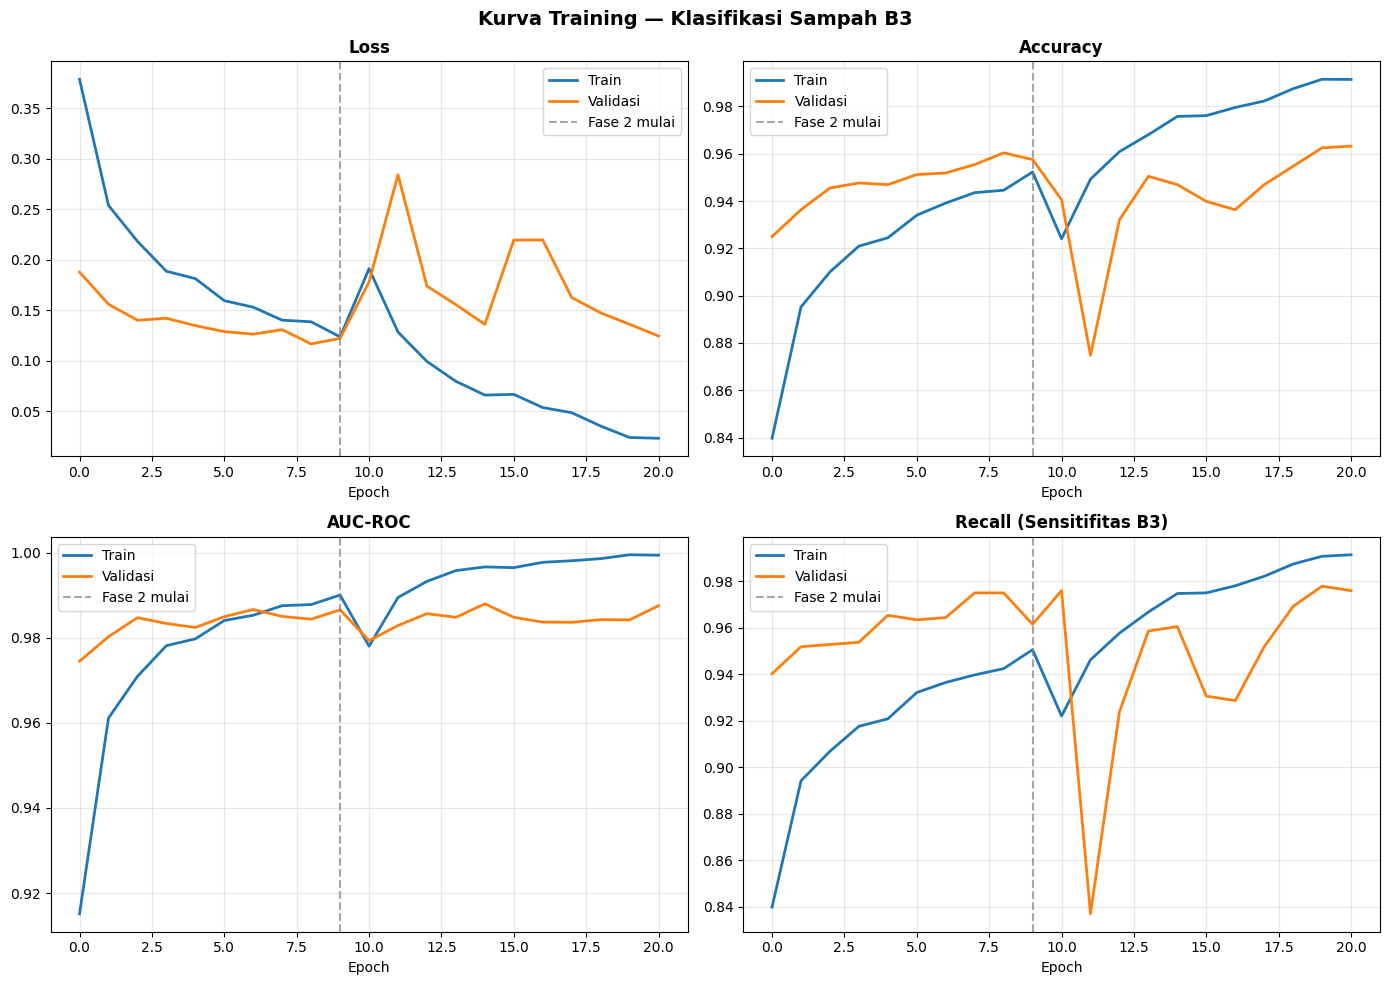

✅ Plot disimpan ke folder project


In [25]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history1, history2)
n_phase1 = len(history1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Kurva Training — Klasifikasi Sampah B3", fontsize=14, fontweight="bold")

for ax, (train_key, val_key, title) in zip(axes.flat, [
    ("loss",     "val_loss",     "Loss"),
    ("accuracy", "val_accuracy", "Accuracy"),
    ("auc",      "val_auc",      "AUC-ROC"),
    ("recall",   "val_recall",   "Recall (Sensitifitas B3)"),
]):
    ax.plot(hist[train_key], label="Train", linewidth=2)
    ax.plot(hist[val_key],   label="Validasi", linewidth=2)
    ax.axvline(n_phase1 - 1, color="gray", linestyle="--", alpha=0.7, label="Fase 2 mulai")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 12. 📊 Evaluasi pada Data Test

In [26]:
print("=" * 60)
print("EVALUASI MODEL PADA DATA TEST")
print("=" * 60)

test_results = model.evaluate(test_ds_proc, verbose=1)
test_metrics = dict(zip(model.metrics_names, test_results))

print("\n📊 Hasil Evaluasi Test Set:")
for name, value in test_metrics.items():
    print(f"   {name:12s} : {value:.4f}")

EVALUASI MODEL PADA DATA TEST
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.9590 - auc: 0.9869 - loss: 0.1224 - precision: 0.9726 - recall: 0.9707

📊 Hasil Evaluasi Test Set:
   loss         : 0.1224
   compile_metrics : 0.9590


## 13. 🔢 Confusion Matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step


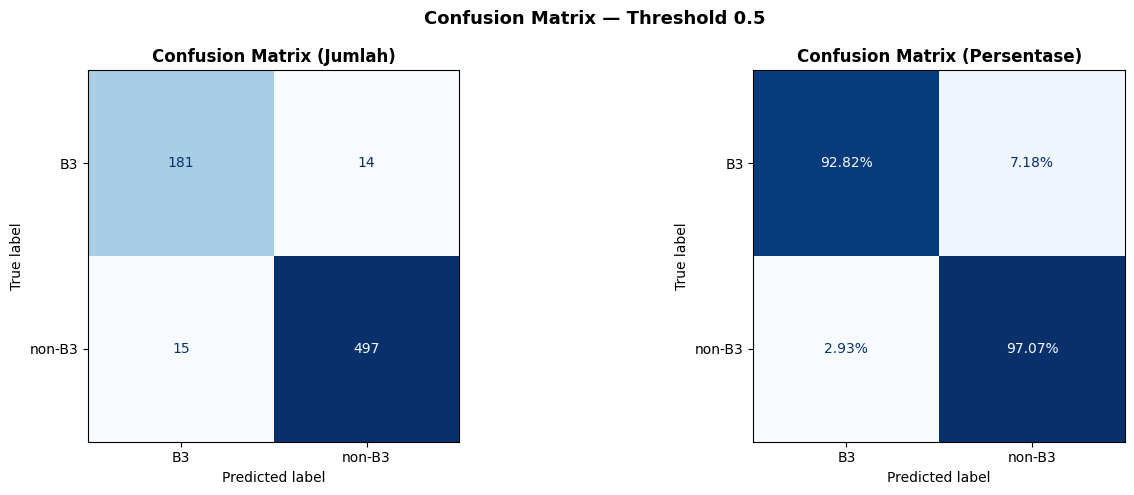

✅ Plot disimpan ke folder project


In [27]:
y_pred_proba = model.predict(test_ds_proc, verbose=1).flatten()
y_true       = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)

THRESHOLD = 0.5
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Jumlah)", fontweight="bold")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%")
axes[1].set_title("Confusion Matrix (Persentase)", fontweight="bold")

plt.suptitle(f"Confusion Matrix — Threshold {THRESHOLD}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 14. 📋 Classification Report

In [28]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

b3_idx    = CLASS_NAMES.index("B3")
prec_b3   = precision_score(y_true, y_pred, pos_label=b3_idx)
recall_b3 = recall_score(y_true, y_pred, pos_label=b3_idx)
f1_b3     = f1_score(y_true, y_pred, pos_label=b3_idx)

print("\n🔴 Fokus kelas B3 (kritis):")
print(f"   Precision : {prec_b3:.4f}")
print(f"   Recall    : {recall_b3:.4f}  ← sensitifitas deteksi B3")
print(f"   F1-Score  : {f1_b3:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          B3     0.9235    0.9282    0.9258       195
      non-B3     0.9726    0.9707    0.9717       512

    accuracy                         0.9590       707
   macro avg     0.9480    0.9495    0.9487       707
weighted avg     0.9591    0.9590    0.9590       707


🔴 Fokus kelas B3 (kritis):
   Precision : 0.9235
   Recall    : 0.9282  ← sensitifitas deteksi B3
   F1-Score  : 0.9258


## 15. 🎯 Threshold Optimal (F1 B3)

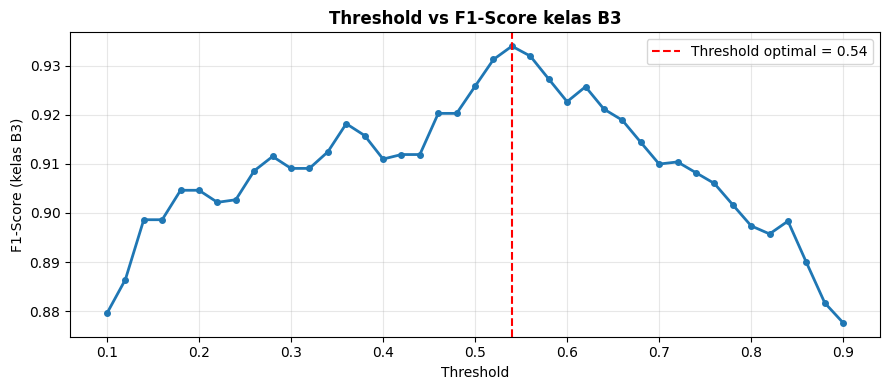


✅ Threshold optimal : 0.54 (F1 B3 = 0.9340)
   Gunakan nilai ini di aplikasi Streamlit!


In [29]:
thresholds    = np.arange(0.1, 0.91, 0.02)
f1_b3_scores  = [f1_score(y_true, (y_pred_proba >= t).astype(int),
                           pos_label=0, zero_division=0) for t in thresholds]

best_t  = thresholds[np.argmax(f1_b3_scores)]
best_f1 = max(f1_b3_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_b3_scores, marker="o", markersize=4, linewidth=2)
plt.axvline(best_t, color="red", linestyle="--", label=f"Threshold optimal = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1-Score (kelas B3)")
plt.title("Threshold vs F1-Score kelas B3", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "threshold_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Threshold optimal : {best_t:.2f} (F1 B3 = {best_f1:.4f})")
print(f"   Gunakan nilai ini di aplikasi Streamlit!")

## 16. 💾 Simpan Model ke Google Drive

In [31]:
# Simpan H5 (legacy, untuk kompatibilitas)
model.save(str(MODEL_PATH))
print(f"✅ Model H5 disimpan → {MODEL_PATH}")

# Simpan format .keras (native Keras 3.x, lebih robust)
keras_path = PROJECT_DIR / "model_b3.keras"
model.save(str(keras_path))
print(f"✅ Model .keras disimpan → {keras_path}")

# Simpan SavedModel (untuk TFLite/TFServing) — pakai export() di Keras 3.x
saved_model_path = PROJECT_DIR / "model_b3_savedmodel"
model.export(str(saved_model_path))
print(f"✅ SavedModel disimpan → {saved_model_path}/")

h5_size = os.path.getsize(str(MODEL_PATH)) / 1e6
print(f"\nUkuran model H5 : {h5_size:.2f} MB")

print("\n📁 Semua file tersimpan di folder project:")
print(f"   {PROJECT_DIR}/")
for fname in ["model_b3.h5", "model_b3.keras", "checkpoint_best.h5"]:
    path = PROJECT_DIR / fname
    exists = "✅" if path.exists() else "❌"
    print(f"   {exists} {fname}")

✅ Model H5 disimpan → model_b3.h5
✅ Model .keras disimpan → model_b3.keras
INFO:tensorflow:Assets written to: model_b3_savedmodel\assets


INFO:tensorflow:Assets written to: model_b3_savedmodel\assets


Saved artifact at 'model_b3_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1946355473040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355474192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355474384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355473616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355472272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355473232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355475920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355475728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355475344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355476496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946355474960: TensorSpec(shape=

## 17. ✅ Ringkasan Hasil

In [32]:
print("=" * 60)
print("  RINGKASAN HASIL TRAINING & EVALUASI")
print("=" * 60)
print(f"  Model         : MobileNetV2 (Transfer Learning)")
print(f"  Input size    : {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
print(f"  Epochs fase 1 : {len(history1.history['loss'])}")
print(f"  Epochs fase 2 : {len(history2.history['loss'])}")
print()
print("  📊 Metrik TEST SET:")
for name, value in test_metrics.items():
    print(f"     {name:12s}: {value:.4f}")
print()
print(f"  🔴 Kelas B3:")
print(f"     Precision : {prec_b3:.4f}")
print(f"     Recall    : {recall_b3:.4f}")
print(f"     F1-Score  : {f1_b3:.4f}")
print()
print(f"  🌐 Threshold untuk Streamlit: {best_t:.2f}")
print(f"  💾 Model tersimpan di Drive  : model_b3.h5")
print("=" * 60)

  RINGKASAN HASIL TRAINING & EVALUASI
  Model         : MobileNetV2 (Transfer Learning)
  Input size    : 224×224 px
  Epochs fase 1 : 10
  Epochs fase 2 : 11

  📊 Metrik TEST SET:
     loss        : 0.1224
     compile_metrics: 0.9590

  🔴 Kelas B3:
     Precision : 0.9235
     Recall    : 0.9282
     F1-Score  : 0.9258

  🌐 Threshold untuk Streamlit: 0.54
  💾 Model tersimpan di Drive  : model_b3.h5
